       RELATÓRIO ESTATÍSTICO DO SISTEMA PETC / OBSERVADOR   
 Período de Amostragem (h)     : 0.1000 s
 Amostras Discretas (s_m)      : 201
 Transmissões ETM (t_k)        : 60
 Redução de Tráfego de Rede    : 70.15% (relativo a s_m)
 Intervalos Inter-Eventos (IET): Média = 0.3356s | Min = 0.1000s | Max = 0.8000s
----------------------------------------------------------
 Erro e1[s_m]: RMS = 0.001787 | Máx Abs = 0.018442
 Erro e2[s_m]: RMS = 0.005148 | Máx Abs = 0.062600


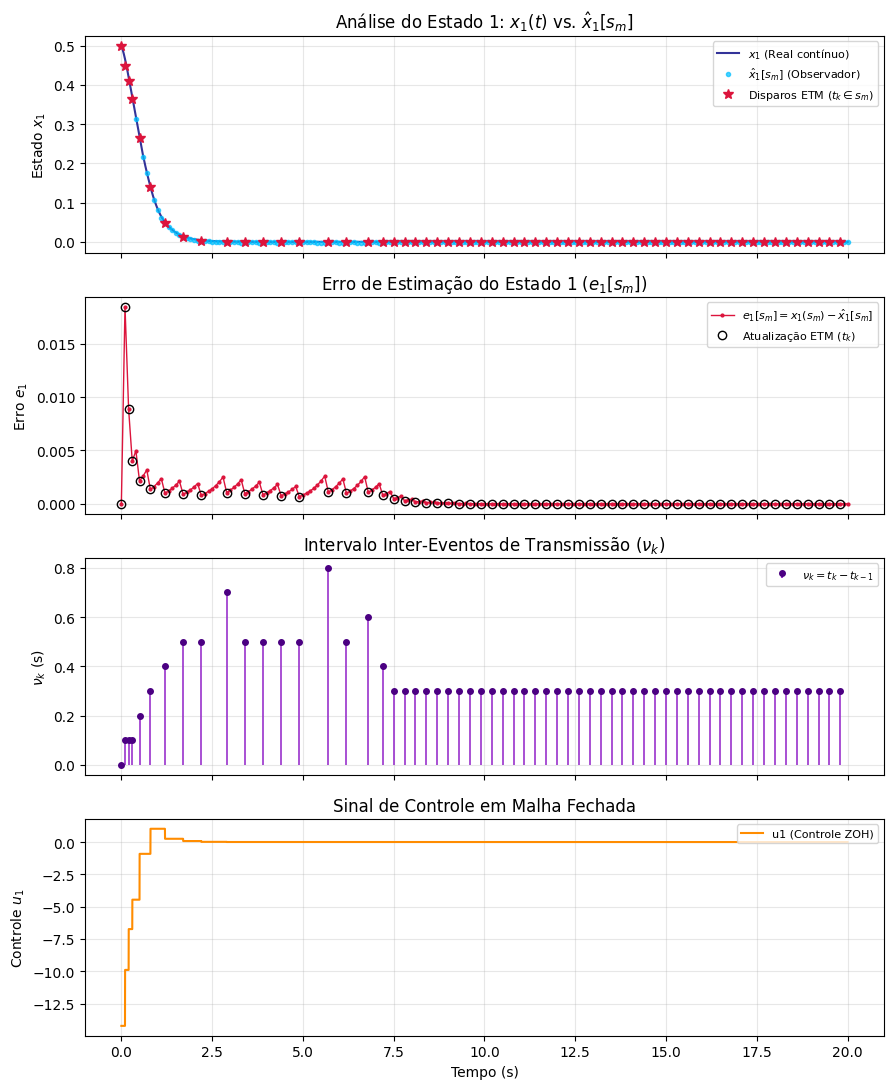

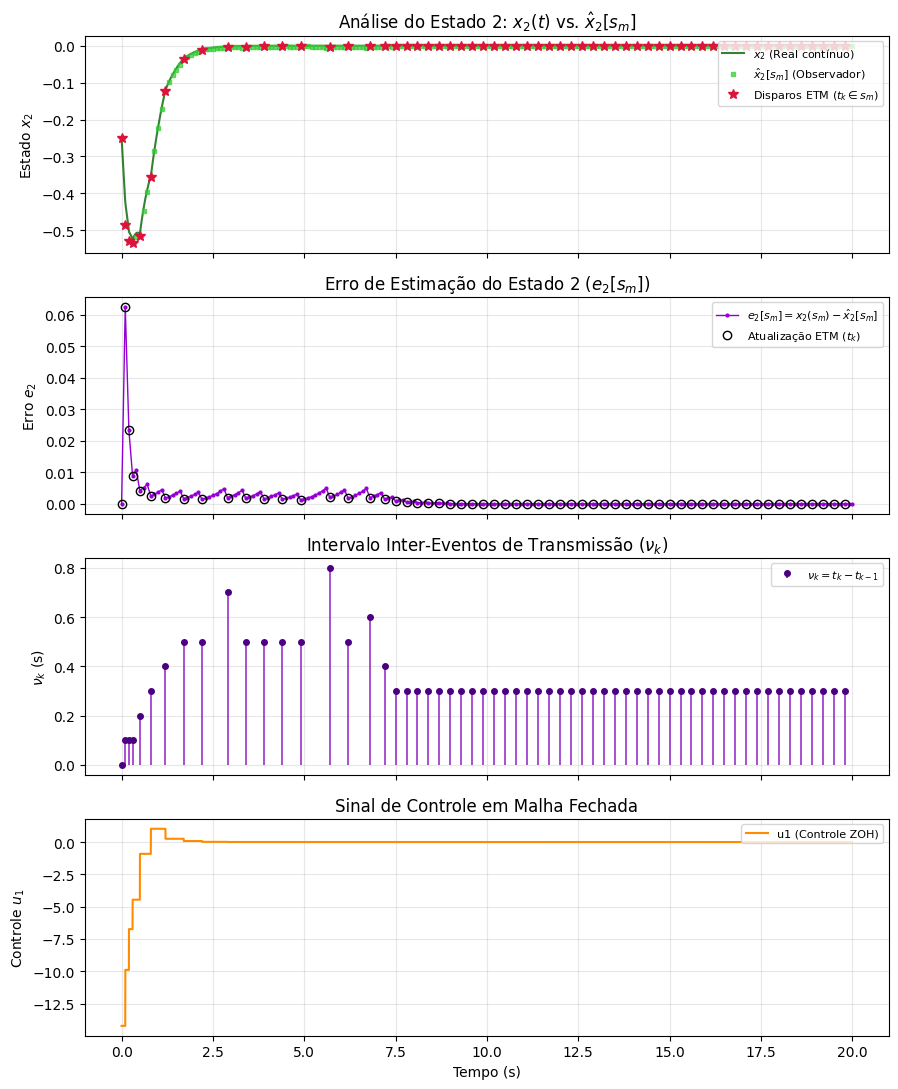

In [21]:
import matplotlib.pyplot as plt
import numpy as np


def load_signal(filepath):
  return np.fromfile(filepath, dtype='float64')


dir_path = 'simulations/lit-system-closed-loop-setm-event-map'

# Período de amostragem fundamental do observador/ETM
h = 0.1

# Carregamento dos vetores de tempo e eventos
time = load_signal(f'{dir_path}/time.bin')
trigger_times = load_signal(f'{dir_path}/trigger_times.bin')

# Carregamento dos estados contínuos, estimados e erros
x1 = load_signal(f'{dir_path}/x1.bin')
x2 = load_signal(f'{dir_path}/x2.bin')
x_est1 = load_signal(f'{dir_path}/x_est1.bin')
x_est2 = load_signal(f'{dir_path}/x_est2.bin')
e1 = load_signal(f'{dir_path}/e1.bin')
e2 = load_signal(f'{dir_path}/e2.bin')
u1 = load_signal(f'{dir_path}/u1.bin')

# -------------------------------------------------------------
# 1. MAPEAMENTO PRECISO DOS INSTANTES DE AMOSTRAGEM s_m (SEM %)
# -------------------------------------------------------------
dt = time[1] - time[0]  # Passo contínuo de integração RK5
step_ratio = int(np.round(h / dt))  # Passos por intervalo h

# Índices exatos da amostragem discreta s_m = m * h
sample_indices = np.arange(0, len(time), step_ratio)
s_m_times = time[sample_indices]

# Extração dos dados restrita estritamente aos instantes s_m
x1_sm = x1[sample_indices]
x2_sm = x2[sample_indices]
x_est1_sm = x_est1[sample_indices]
x_est2_sm = x_est2[sample_indices]
e1_sm = e1[sample_indices]
e2_sm = e2[sample_indices]

# Mapeamento dos instantes de disparo t_k (subconjunto de s_m)
trig_indices = np.searchsorted(time, trigger_times)
trig_indices = np.clip(trig_indices, 0, len(time) - 1)

x_est1_trig = x_est1[trig_indices]
x_est2_trig = x_est2[trig_indices]
e1_trig = e1[trig_indices]
e2_trig = e2[trig_indices]

# -------------------------------------------------------------
# 2. CÁLCULO DAS ESTATÍSTICAS DISCRETAS DO SISTEMA
# -------------------------------------------------------------
inter_event_times = np.zeros_like(trigger_times)
if len(trigger_times) > 1:
  inter_event_times[1:] = np.diff(trigger_times)

iet_mean = np.mean(inter_event_times[1:]) if len(
    inter_event_times) > 1 else 0.0
iet_min = np.min(inter_event_times[1:]) if len(inter_event_times) > 1 else 0.0
iet_max = np.max(inter_event_times[1:]) if len(inter_event_times) > 1 else 0.0
total_transmissions = len(trigger_times)
total_samples_sm = len(s_m_times)
reduction_pct = (1.0 - (total_transmissions / total_samples_sm)) * 100.0

e1_rms = np.sqrt(np.mean(e1_sm**2))
e2_rms = np.sqrt(np.mean(e2_sm**2))
e1_max = np.max(np.abs(e1_sm))
e2_max = np.max(np.abs(e2_sm))

print("==========================================================")
print("       RELATÓRIO ESTATÍSTICO DO SISTEMA PETC / OBSERVADOR   ")
print("==========================================================")
print(f" Período de Amostragem (h)     : {h:.4f} s")
print(f" Amostras Discretas (s_m)      : {total_samples_sm}")
print(f" Transmissões ETM (t_k)        : {total_transmissions}")
print(
    f" Redução de Tráfego de Rede    : {reduction_pct:.2f}% (relativo a s_m)")
print(
    f" Intervalos Inter-Eventos (IET): Média = {iet_mean:.4f}s | Min = {iet_min:.4f}s | Max = {iet_max:.4f}s")
print("----------------------------------------------------------")
print(f" Erro e1[s_m]: RMS = {e1_rms:.6f} | Máx Abs = {e1_max:.6f}")
print(f" Erro e2[s_m]: RMS = {e2_rms:.6f} | Máx Abs = {e2_max:.6f}")
print("==========================================================")


# =============================================================
# 3. PLOTAGEM DO ESTADO 1 EM FIGURA ISOLADA
# =============================================================
fig1, (ax1_1, ax1_2, ax1_3, ax1_4) = plt.subplots(
    4, 1, figsize=(9, 11), sharex=True)

# 1. Estado x1 Real vs Estimado
ax1_1.plot(time, x1, label='$x_1$ (Real contínuo)',
           color='navy', linewidth=1.5, alpha=0.8)
ax1_1.plot(s_m_times, x_est1_sm, label=r'$\hat{x}_1[s_m]$ (Observador)',
           color='deepskyblue', linestyle='none', marker='o', markersize=3, alpha=0.7)
ax1_1.plot(trigger_times, x_est1_trig, label=r'Disparos ETM ($t_k \in s_m$)',
           color='crimson', linestyle='none', marker='*', markersize=7)
ax1_1.set_title(r'Análise do Estado 1: $x_1(t)$ vs. $\hat{x}_1[s_m]$')
ax1_1.set_ylabel('Estado $x_1$')
ax1_1.legend(loc='upper right', fontsize=8)
ax1_1.grid(True, alpha=0.3)

# 2. Erro do Estado 1
ax1_2.plot(s_m_times, e1_sm, label=r'$e_1[s_m] = x_1(s_m) - \hat{x}_1[s_m]$',
           color='crimson', linestyle='-', marker='.', markersize=4, linewidth=1.0)
ax1_2.plot(trigger_times, e1_trig, color='black', linestyle='none', marker='o',
           markersize=6, fillstyle='none', label=r'Atualização ETM ($t_k$)')
ax1_2.set_title(r'Erro de Estimação do Estado 1 ($e_1[s_m]$)')
ax1_2.set_ylabel('Erro $e_1$')
ax1_2.legend(loc='upper right', fontsize=8)
ax1_2.grid(True, alpha=0.3)

# 3. Intervalo Inter-Eventos (\nu_k)
marker_ev1, stem_ev1, base_ev1 = ax1_3.stem(
    trigger_times, inter_event_times, linefmt='purple', markerfmt='purple', label=r'$\nu_k = t_k - t_{k-1}$'
)
plt.setp(stem_ev1, color='darkorchid', linewidth=1.2)
plt.setp(marker_ev1, markersize=4, color='indigo')
base_ev1.set_visible(False)
ax1_3.set_title(r'Intervalo Inter-Eventos de Transmissão ($\nu_k$)')
ax1_3.set_ylabel(r'$\nu_k$ (s)')
ax1_3.legend(loc='upper right', fontsize=8)
ax1_3.grid(True, alpha=0.3)

# 4. Sinal de Controle u(t)
ax1_4.plot(time, u1, label='u1 (Controle ZOH)',
           color='darkorange', linewidth=1.5)
ax1_4.set_title('Sinal de Controle em Malha Fechada')
ax1_4.set_xlabel('Tempo (s)')
ax1_4.set_ylabel('Controle $u_1$')
ax1_4.legend(loc='upper right', fontsize=8)
ax1_4.grid(True, alpha=0.3)

fig1.tight_layout()
plt.show()


# =============================================================
# 4. PLOTAGEM DO ESTADO 2 EM FIGURA ISOLADA
# =============================================================
fig2, (ax2_1, ax2_2, ax2_3, ax2_4) = plt.subplots(
    4, 1, figsize=(9, 11), sharex=True)

# 1. Estado x2 Real vs Estimado
ax2_1.plot(time, x2, label='$x_2$ (Real contínuo)',
           color='darkgreen', linewidth=1.5, alpha=0.8)
ax2_1.plot(s_m_times, x_est2_sm, label=r'$\hat{x}_2[s_m]$ (Observador)',
           color='limegreen', linestyle='none', marker='s', markersize=3, alpha=0.7)
ax2_1.plot(trigger_times, x_est2_trig, label=r'Disparos ETM ($t_k \in s_m$)',
           color='crimson', linestyle='none', marker='*', markersize=7)
ax2_1.set_title(r'Análise do Estado 2: $x_2(t)$ vs. $\hat{x}_2[s_m]$')
ax2_1.set_ylabel('Estado $x_2$')
ax2_1.legend(loc='upper right', fontsize=8)
ax2_1.grid(True, alpha=0.3)

# 2. Erro do Estado 2
ax2_2.plot(s_m_times, e2_sm, label=r'$e_2[s_m] = x_2(s_m) - \hat{x}_2[s_m]$',
           color='darkviolet', linestyle='-', marker='.', markersize=4, linewidth=1.0)
ax2_2.plot(trigger_times, e2_trig, color='black', linestyle='none', marker='o',
           markersize=6, fillstyle='none', label=r'Atualização ETM ($t_k$)')
ax2_2.set_title(r'Erro de Estimação do Estado 2 ($e_2[s_m]$)')
ax2_2.set_ylabel('Erro $e_2$')
ax2_2.legend(loc='upper right', fontsize=8)
ax2_2.grid(True, alpha=0.3)

# 3. Intervalo Inter-Eventos (\nu_k)
marker_ev2, stem_ev2, base_ev2 = ax2_3.stem(
    trigger_times, inter_event_times, linefmt='purple', markerfmt='purple', label=r'$\nu_k = t_k - t_{k-1}$'
)
plt.setp(stem_ev2, color='darkorchid', linewidth=1.2)
plt.setp(marker_ev2, markersize=4, color='indigo')
base_ev2.set_visible(False)
ax2_3.set_title(r'Intervalo Inter-Eventos de Transmissão ($\nu_k$)')
ax2_3.set_ylabel(r'$\nu_k$ (s)')
ax2_3.legend(loc='upper right', fontsize=8)
ax2_3.grid(True, alpha=0.3)

# 4. Sinal de Controle u(t)
ax2_4.plot(time, u1, label='u1 (Controle ZOH)',
           color='darkorange', linewidth=1.5)
ax2_4.set_title('Sinal de Controle em Malha Fechada')
ax2_4.set_xlabel('Tempo (s)')
ax2_4.set_ylabel('Controle $u_1$')
ax2_4.legend(loc='upper right', fontsize=8)
ax2_4.grid(True, alpha=0.3)

fig2.tight_layout()
plt.show()

                 RELATÓRIO ESTATÍSTICO PETC               
 Transmissões ETM              : 54
 Intervalos Inter-Eventos      : Média = 0.2830s | Min = 0.1000s | Max = 0.4000s


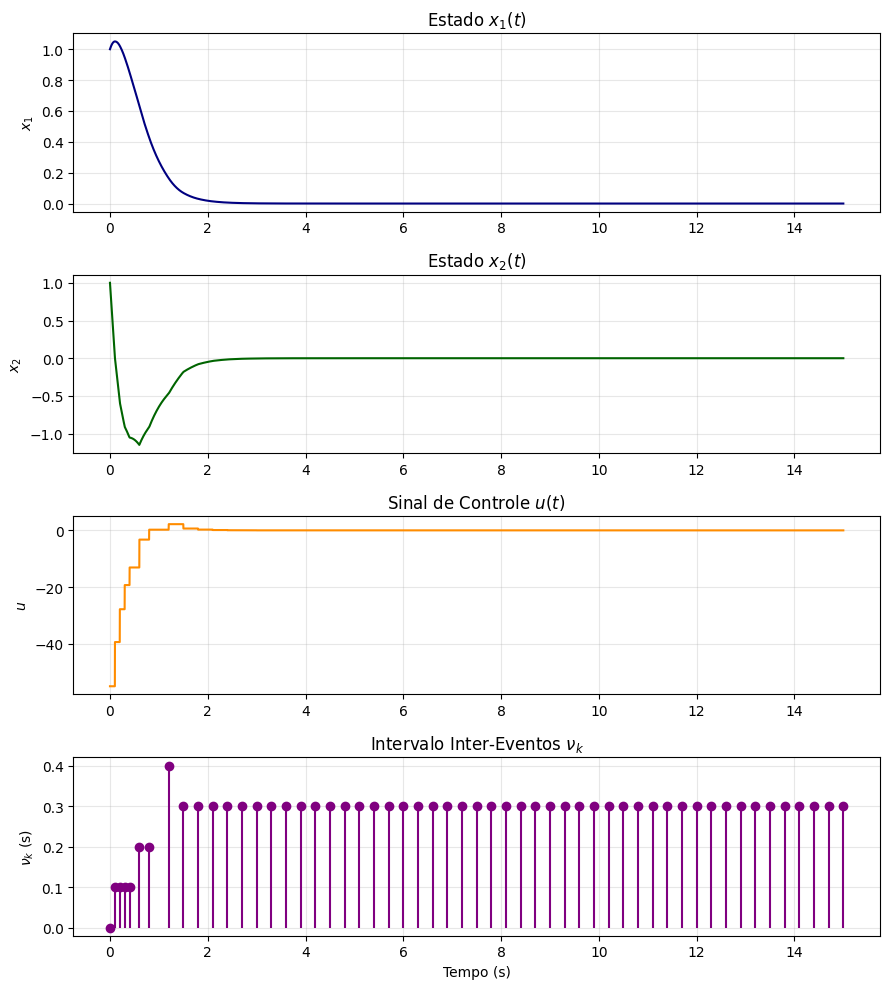

In [14]:
import matplotlib.pyplot as plt
import numpy as np


def load_signal(filepath):
  return np.fromfile(filepath, dtype='float64')


dir_path = 'simulations/lit-system-closed-loop-setm'

# -------------------------------------------------------------
# 1. LOAD SIGNALS
# -------------------------------------------------------------
time = load_signal(f'{dir_path}/time.bin')
trigger_times = load_signal(f'{dir_path}/trigger_times.bin')

x1 = load_signal(f'{dir_path}/x1.bin')
x2 = load_signal(f'{dir_path}/x2.bin')
u1 = load_signal(f'{dir_path}/u1.bin')


# -------------------------------------------------------------
# 2. INTER-EVENT TIMES
# -------------------------------------------------------------
inter_event_times = np.zeros_like(trigger_times)

if len(trigger_times) > 1:
  inter_event_times[1:] = np.diff(trigger_times)


# -------------------------------------------------------------
# 3. STATISTICS
# -------------------------------------------------------------
iet = inter_event_times[1:] if len(inter_event_times) > 1 else np.array([])

iet_mean = np.mean(iet) if len(iet) > 0 else 0.0
iet_min = np.min(iet) if len(iet) > 0 else 0.0
iet_max = np.max(iet) if len(iet) > 0 else 0.0

total_transmissions = len(trigger_times)

print("==========================================================")
print("                 RELATÓRIO ESTATÍSTICO PETC               ")
print("==========================================================")
print(f" Transmissões ETM              : {total_transmissions}")
print(
    f" Intervalos Inter-Eventos      : "
    f"Média = {iet_mean:.4f}s | "
    f"Min = {iet_min:.4f}s | "
    f"Max = {iet_max:.4f}s"
)
print("==========================================================")


# =============================================================
# 4. PLOTAGEM
# =============================================================
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    4, 1,
    figsize=(9, 10),
    sharex=False
)


# -------------------------------------------------------------
# Estado x1
# -------------------------------------------------------------
ax1.plot(
    time,
    x1,
    color='navy',
    linewidth=1.5
)

ax1.set_title(r'Estado $x_1(t)$')
ax1.set_ylabel(r'$x_1$')
ax1.grid(True, alpha=0.3)


# -------------------------------------------------------------
# Estado x2
# -------------------------------------------------------------
ax2.plot(
    time,
    x2,
    color='darkgreen',
    linewidth=1.5
)

ax2.set_title(r'Estado $x_2(t)$')
ax2.set_ylabel(r'$x_2$')
ax2.grid(True, alpha=0.3)


# -------------------------------------------------------------
# Sinal de controle
# -------------------------------------------------------------
ax3.plot(
    time,
    u1,
    color='darkorange',
    linewidth=1.5
)

ax3.set_title(r'Sinal de Controle $u(t)$')
ax3.set_ylabel(r'$u$')
ax3.grid(True, alpha=0.3)


# -------------------------------------------------------------
# Intervalo entre eventos
# -------------------------------------------------------------
ax4.stem(
    trigger_times,
    inter_event_times,
    linefmt='purple',
    markerfmt='o',
    basefmt=' '
)

ax4.set_title(r'Intervalo Inter-Eventos $\nu_k$')
ax4.set_xlabel('Tempo (s)')
ax4.set_ylabel(r'$\nu_k$ (s)')
ax4.grid(True, alpha=0.3)


fig.tight_layout()
plt.show()